Test Accuracy (fixed seed): 73.74%

Classification Report:
               precision    recall  f1-score   support

       DC_L1       0.35      0.28      0.31        96
       DC_L2       0.43      0.54      0.48        96
       DC_L3       0.55      0.56      0.55        96
       DC_L4       0.56      0.49      0.52        96
       DC_L5       0.58      0.54      0.56        96
        LG_R       0.80      0.83      0.82        96
        LG_S       0.99      0.98      0.98        96
       LLG_R       0.81      0.79      0.80        96
       LLG_S       0.97      0.98      0.97        96
       LLL_R       0.76      0.81      0.79        96
       LLL_S       0.76      0.83      0.80        96
        LL_R       0.83      0.82      0.83        96
        LL_S       0.92      0.85      0.89        96
    No Fault       1.00      1.00      1.00        96

    accuracy                           0.74      1344
   macro avg       0.74      0.74      0.74      1344
weighted avg       0

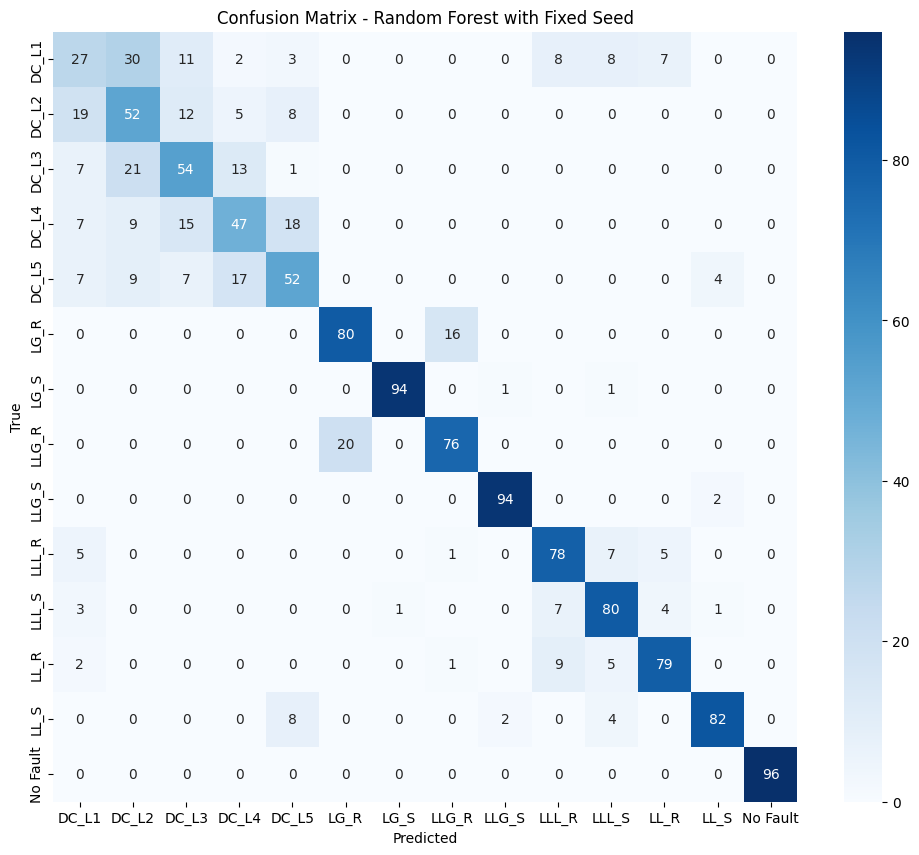

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (update file path)
dataset_path = "/content/HVDC_Dataset.csv"
df = pd.read_csv(dataset_path)

# Define fault label columns (one-hot encoding) and convert to single label column
fault_label_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                    'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                    'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
df['fault_label'] = df[fault_label_cols].idxmax(axis=1)

# Define feature columns
feature_cols = ['Rf_Ohm',
                'Uabc_B1_pu__C1_RMS', 'Uabc_B1_pu__C2_RMS', 'Uabc_B1_pu__C3_RMS',
                'Iabc_B1_pu__C1_RMS', 'Iabc_B1_pu__C2_RMS', 'Iabc_B1_pu__C3_RMS',
                'P_measPref_pu__C1_RMS', 'Q_measQref_pu__C1_RMS',
                'IdcPN_A__C1_RMS', 'IdcPN_A__C2_RMS',
                'VdcPN_V__C1_RMS', 'VdcPN_V__C2_RMS',
                'Uabc_B2_pu__C1_RMS', 'Uabc_B2_pu__C2_RMS', 'Uabc_B2_pu__C3_RMS',
                'Iabc_B2_pu__C1_RMS', 'Iabc_B2_pu__C2_RMS', 'Iabc_B2_pu__C3_RMS',
                'P_measPref2_pu__C1_RMS', 'Q_measQref2_pu__C1_RMS',
                'IdcPN2_A__C1_RMS', 'IdcPN2_A__C2_RMS',
                'VdcPN2_V__C1_RMS', 'VdcPN2_V__C2_RMS']

X = df[feature_cols].values
y = df['fault_label'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set a fixed random seed
RANDOM_STATE = 42

# Split dataset into train/test preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Create Random Forest with fixed random_state for reproducibility
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1)

# Train model
rf_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (fixed seed): {accuracy*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix visualization
cf_matrix = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_clf.classes_,
            yticklabels=rf_clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest with Fixed Seed')
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (update file path)
dataset_path = "/content/HVDC_Dataset.csv"
df = pd.read_csv(dataset_path)

# Define fault label columns (one-hot encoding) and convert to single label column
fault_label_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                    'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                    'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
df['fault_label'] = df[fault_label_cols].idxmax(axis=1)

# Define feature columns
feature_cols = ['Rf_Ohm',
                'Uabc_B1_pu__C1_RMS', 'Uabc_B1_pu__C2_RMS', 'Uabc_B1_pu__C3_RMS',
                'Iabc_B1_pu__C1_RMS', 'Iabc_B1_pu__C2_RMS', 'Iabc_B1_pu__C3_RMS',
                'P_measPref_pu__C1_RMS', 'Q_measQref_pu__C1_RMS',
                'IdcPN_A__C1_RMS', 'IdcPN_A__C2_RMS',
                'VdcPN_V__C1_RMS', 'VdcPN_V__C2_RMS',
                'Uabc_B2_pu__C1_RMS', 'Uabc_B2_pu__C2_RMS', 'Uabc_B2_pu__C3_RMS',
                'Iabc_B2_pu__C1_RMS', 'Iabc_B2_pu__C2_RMS', 'Iabc_B2_pu__C3_RMS',
                'P_measPref2_pu__C1_RMS', 'Q_measQref2_pu__C1_RMS',
                'IdcPN2_A__C1_RMS', 'IdcPN2_A__C2_RMS',
                'VdcPN2_V__C1_RMS', 'VdcPN2_V__C2_RMS']

X = df[feature_cols].values
y = df['fault_label'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set a fixed random seed
RANDOM_STATE = 42

# Split dataset into train/test preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define base RF classifier (random_state set for reproducibility)
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Define hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Instantiate GridSearchCV with 5-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

# Run GridSearch on training data to find best hyperparameters
grid_search.fit(X_train, y_train)

# Use the best estimator found by GridSearch
best_rf = grid_search.best_estimator_


# Predict and evaluate
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (fixed seed): {accuracy*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix visualization
cf_matrix = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_clf.classes_,
            yticklabels=rf_clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest with Fixed Seed')
plt.show()


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
